In [30]:
import pandas as pd
import numpy as np

In [31]:
df = pd.read_csv("Fish.csv")
df.head()

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


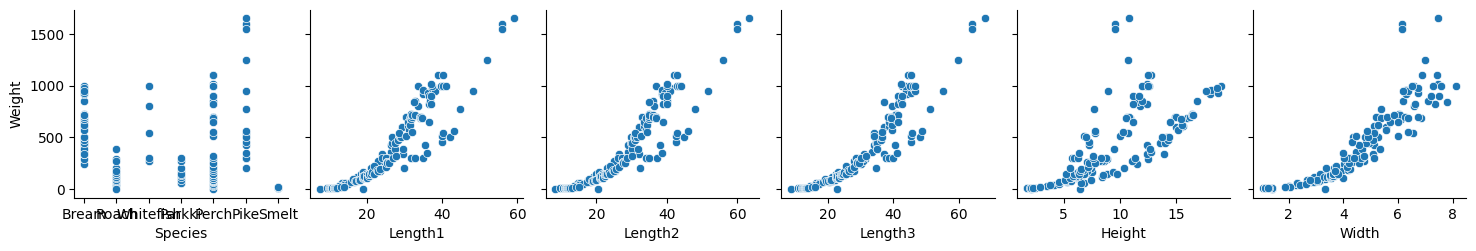

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(df, y_vars=["Weight"], x_vars=[col for col in df.columns if col != "Weight"])
plt.show()


In [8]:
X = df.drop("Weight", axis=1)
y = df["Weight"]

num_features = X.select_dtypes(include="number").columns
cat_features = X.select_dtypes(exclude="number").columns


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [27]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge

baseline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyRegressor(strategy="mean"))
    ]
)

baseline.fit(X_train, y_train)
y_pred_baseline = baseline.predict(X_test)

ridge = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Ridge(alpha=1.0))
    ]
)

ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)


In [28]:
baseline_mse = mean_squared_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(baseline_mse)

model_mse = mean_squared_error(y_test, y_pred_ridge)
model_rmse = np.sqrt(model_mse)
